<a href="https://colab.research.google.com/github/BijoyRoyxxx/AI-enabled-Low-Cost-Real-Time-Mine-Subsidence-Monitoring-Prediction-and-Early-Warning-System-/blob/main/ANANYA_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [30]:
from google.colab import files
import pandas as pd
import numpy as np

uploaded = files.upload()

filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

print("Dataset shape:", df.shape)
print(df.columns.tolist())
display(df.head())

Saving mine_subsidence_100k_synthetic_ml_dataset.csv to mine_subsidence_100k_synthetic_ml_dataset (1).csv
Dataset shape: (100000, 25)
['timestamp_utc', 'node_id', 'latitude', 'longitude', 'temperature_c', 'humidity_pct', 'rainfall_mm', 'tilt_x_deg', 'tilt_y_deg', 'tilt_magnitude_deg', 'tilt_rate_deg_per_hour', 'relative_displacement_mm', 'displacement_rate_mm_per_hour', 'displacement_accel_mm_per_hour2', 'disp_1h_change_mm', 'crack_width_mm', 'crack_growth_mm_per_hour', 'crack_growth_accel_mm_per_hour2', 'crack_1h_change_mm', 'vibration_g', 'vibration_rms_1h_g', 'tilt_6h_max_deg', 'risk_score', 'risk_class', 'synthetic_event']


,timestamp_utc,node_id,latitude,longitude,temperature_c,humidity_pct,rainfall_mm,tilt_x_deg,tilt_y_deg,tilt_magnitude_deg,...,crack_width_mm,crack_growth_mm_per_hour,crack_growth_accel_mm_per_hour2,crack_1h_change_mm,vibration_g,vibration_rms_1h_g,tilt_6h_max_deg,risk_score,risk_class,synthetic_event
0,2026-01-01 00:00:00+00:00,1,23.795,86.385,29.835741,69.145144,1.276357,-0.044199,-0.001172,0.044214,...,0.012764,0.000000,0.000000,0.0,0.010129,0.010129,0.044214,0.4605,NORMAL,0
1,2026-01-01 00:10:00+00:00,1,23.795,86.385,28.998371,67.065050,0.000000,0.036714,0.030579,0.047780,...,0.086097,0.439999,0.000000,0.0,0.013499,0.011934,0.047780,1.6702,NORMAL,0
2,2026-01-01 00:20:00+00:00,1,23.795,86.385,29.006472,66.764686,0.155880,0.023766,0.011466,0.026387,...,0.120155,0.204348,-1.413906,0.0,0.016909,0.013793,0.047780,2.2871,WATCH,0
3,2026-01-01 00:30:00+00:00,1,23.795,86.385,29.458690,66.004573,1.623347,-0.023126,-0.016679,0.028513,...,0.119495,-0.003959,-1.249839,0.0,0.013955,0.013834,0.047780,0.9154,NORMAL,0
4,2026-01-01 00:40:00+00:00,1,23.795,86.385,28.619793,66.944053,0.000000,-0.000435,0.002048,0.002093,...,0.073099,-0.278375,-1.646494,0.0,0.024247,0.016452,0.047780,0.4943,NORMAL,0


In [31]:
df["timestamp_utc"] = pd.to_datetime(df["timestamp_utc"], utc=True)

df = df.sort_values(["node_id", "timestamp_utc"]).reset_index(drop=True)

target = "synthetic_event"

features = [
    "temperature_c",
    "humidity_pct",
    "rainfall_mm",
    "tilt_x_deg",
    "tilt_y_deg",
    "tilt_magnitude_deg",
    "tilt_rate_deg_per_hour",
    "relative_displacement_mm",
    "displacement_rate_mm_per_hour",
    "displacement_accel_mm_per_hour2",
    "disp_1h_change_mm",
    "crack_width_mm",
    "crack_growth_mm_per_hour",
    "crack_growth_accel_mm_per_hour2",
    "crack_1h_change_mm",
    "vibration_g",
    "vibration_rms_1h_g",
    "tilt_6h_max_deg"
]

X = df[features].copy()
y = df[target].astype(int)

print("Features:", X.shape)
print("Target distribution:")
print(y.value_counts())
print("\nEvent percentage:")
print(y.mean() * 100)

Features: (100000, 18)
Target distribution:
synthetic_event
0    92045
1     7955
Name: count, dtype: int64

Event percentage:
7.954999999999999


In [32]:
from sklearn.model_selection import train_test_split

split_index = int(len(df) * 0.8)

train_df = df.iloc[:split_index].copy()
test_df = df.iloc[split_index:].copy()

X_train = train_df[features]
y_train = train_df[target].astype(int)

X_test = test_df[features]
y_test = test_df[target].astype(int)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("\nTraining events:", y_train.sum())
print("Testing events:", y_test.sum())

Training samples: 80000
Testing samples: 20000

Training events: 6970
Testing events: 985


In [33]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=18,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


In [34]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print(f"Accuracy : {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision: {precision:.4f} ({precision*100:.2f}%)")
print(f"Recall   : {recall:.4f} ({recall*100:.2f}%)")
print(f"F1 Score : {f1:.4f} ({f1*100:.2f}%)")
print(f"ROC-AUC  : {roc_auc:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))

Accuracy : 0.9980 (99.80%)
Precision: 0.9628 (96.28%)
Recall   : 0.9990 (99.90%)
F1 Score : 0.9806 (98.06%)
ROC-AUC  : 1.0000

Confusion Matrix:
[[18977    38]
 [    1   984]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9999    0.9980    0.9990     19015
           1     0.9628    0.9990    0.9806       985

    accuracy                         0.9980     20000
   macro avg     0.9814    0.9985    0.9898     20000
weighted avg     0.9981    0.9980    0.9981     20000



In [35]:
importance = pd.DataFrame({
    "feature": features,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

display(importance)

,feature,importance
11,crack_width_mm,0.275049
16,vibration_rms_1h_g,0.233391
7,relative_displacement_mm,0.190599
17,tilt_6h_max_deg,0.095116
15,vibration_g,0.091629
3,tilt_x_deg,0.040742
5,tilt_magnitude_deg,0.036019
4,tilt_y_deg,0.020690
14,crack_1h_change_mm,0.007496
10,disp_1h_change_mm,0.002044


In [36]:
correlation = df[features + ["synthetic_event"]].corr()["synthetic_event"].drop("synthetic_event").abs().sort_values(ascending=False)

display(correlation.to_frame("absolute_correlation"))

,absolute_correlation
crack_width_mm,0.834854
vibration_rms_1h_g,0.822291
relative_displacement_mm,0.815534
vibration_g,0.771538
tilt_6h_max_deg,0.749633
tilt_magnitude_deg,0.654125
tilt_x_deg,0.613518
tilt_y_deg,0.520621
crack_1h_change_mm,0.032782
disp_1h_change_mm,0.015502


In [37]:
train_end = int(len(df) * 0.70)
val_end = int(len(df) * 0.85)

train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

X_train = train_df[features]
y_train = train_df[target].astype(int)

X_val = val_df[features]
y_val = val_df[target].astype(int)

X_test = test_df[features]
y_test = test_df[target].astype(int)

print("Train:", X_train.shape, "Events:", y_train.sum())
print("Validation:", X_val.shape, "Events:", y_val.sum())
print("Test:", X_test.shape, "Events:", y_test.sum())

Train: (70000, 18) Events: 6112
Validation: (15000, 18) Events: 1159
Test: (15000, 18) Events: 684


In [38]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=18,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

print("Training completed.")

Training completed.


In [39]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

y_val_pred = model.predict(X_val)
y_val_prob = model.predict_proba(X_val)[:, 1]

y_test_pred = model.predict(X_test)
y_test_prob = model.predict_proba(X_test)[:, 1]

print("VALIDATION RESULTS")
print(f"Accuracy : {accuracy_score(y_val, y_val_pred):.4f}")
print(f"Precision: {precision_score(y_val, y_val_pred):.4f}")
print(f"Recall   : {recall_score(y_val, y_val_pred):.4f}")
print(f"F1 Score : {f1_score(y_val, y_val_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_val, y_val_prob):.4f}")

print("\nTEST RESULTS")
print(f"Accuracy : {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_test_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_test_pred):.4f}")
print(f"F1 Score : {f1_score(y_test, y_test_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_test_prob):.4f}")

print("\nTEST CONFUSION MATRIX")
print(confusion_matrix(y_test, y_test_pred))

print("\nTEST CLASSIFICATION REPORT")
print(classification_report(y_test, y_test_pred, digits=4))

VALIDATION RESULTS
Accuracy : 0.9979
Precision: 0.9755
Recall   : 0.9983
F1 Score : 0.9868
ROC-AUC  : 1.0000

TEST RESULTS
Accuracy : 0.9977
Precision: 0.9539
Recall   : 0.9985
F1 Score : 0.9757
ROC-AUC  : 0.9999

TEST CONFUSION MATRIX
[[14283    33]
 [    1   683]]

TEST CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0     0.9999    0.9977    0.9988     14316
           1     0.9539    0.9985    0.9757       684

    accuracy                         0.9977     15000
   macro avg     0.9769    0.9981    0.9873     15000
weighted avg     0.9978    0.9977    0.9978     15000



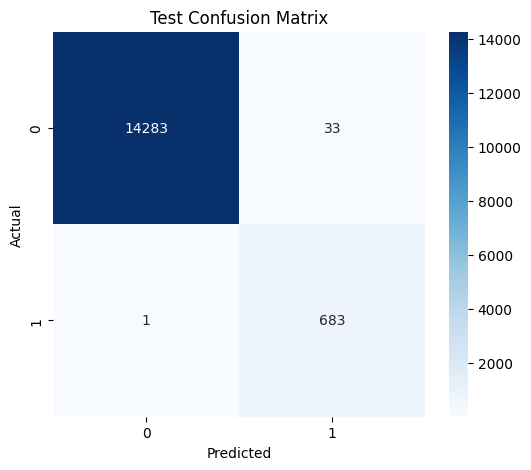

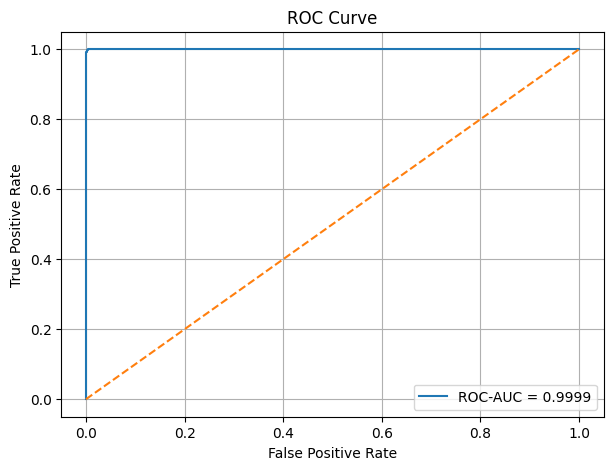

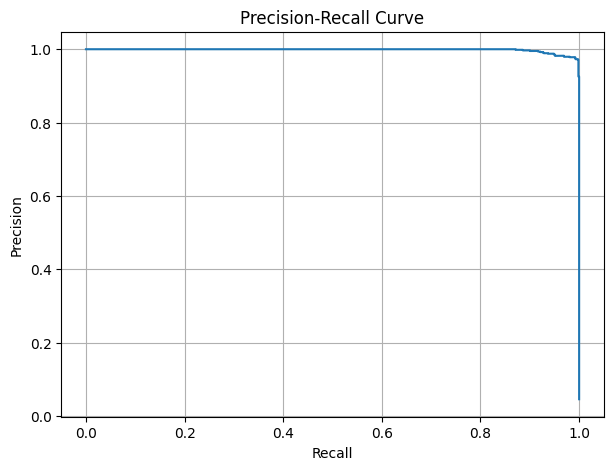

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    precision_recall_curve
)

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Test Confusion Matrix")
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_test_prob)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc_score(y_test, y_test_prob):.4f}")
plt.plot([0,1], [0,1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()

precision, recall, _ = precision_recall_curve(y_test, y_test_prob)

plt.figure(figsize=(7,5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid()
plt.show()

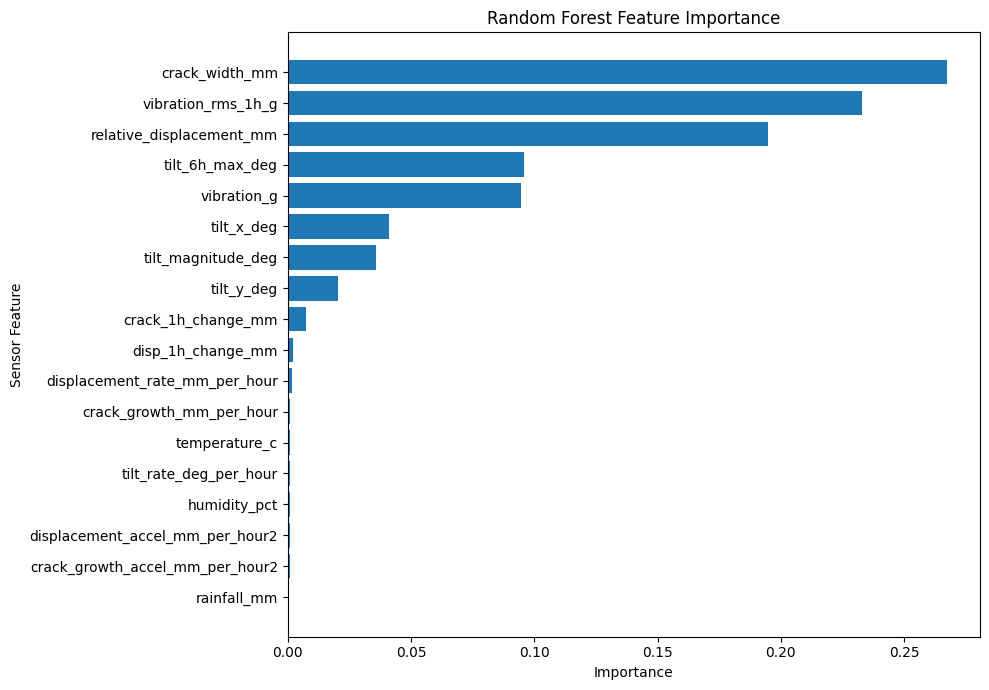

In [41]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values("Importance", ascending=True)

plt.figure(figsize=(10,7))
plt.barh(importance["Feature"], importance["Importance"])
plt.xlabel("Importance")
plt.ylabel("Sensor Feature")
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()

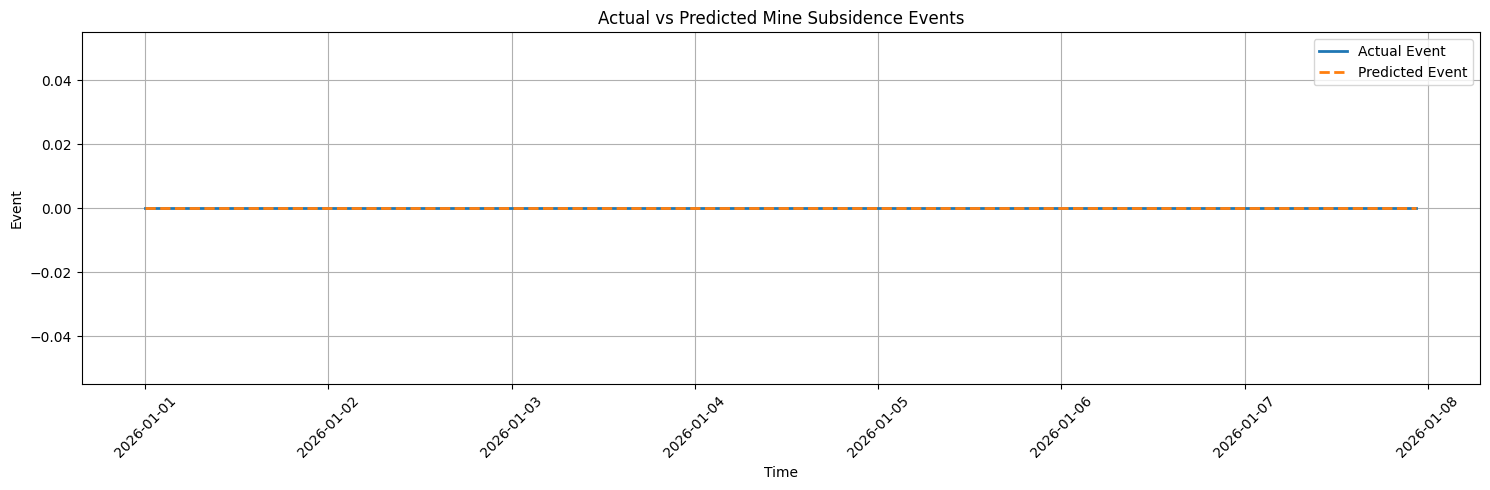

In [42]:
import matplotlib.pyplot as plt

n = 1000

plt.figure(figsize=(15,5))
plt.plot(
    test_df["timestamp_utc"].iloc[:n],
    y_test.iloc[:n].values,
    label="Actual Event",
    linewidth=2
)
plt.plot(
    test_df["timestamp_utc"].iloc[:n],
    y_test_pred[:n],
    label="Predicted Event",
    linestyle="--",
    linewidth=2
)

plt.xlabel("Time")
plt.ylabel("Event")
plt.title("Actual vs Predicted Mine Subsidence Events")
plt.legend()
plt.grid()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

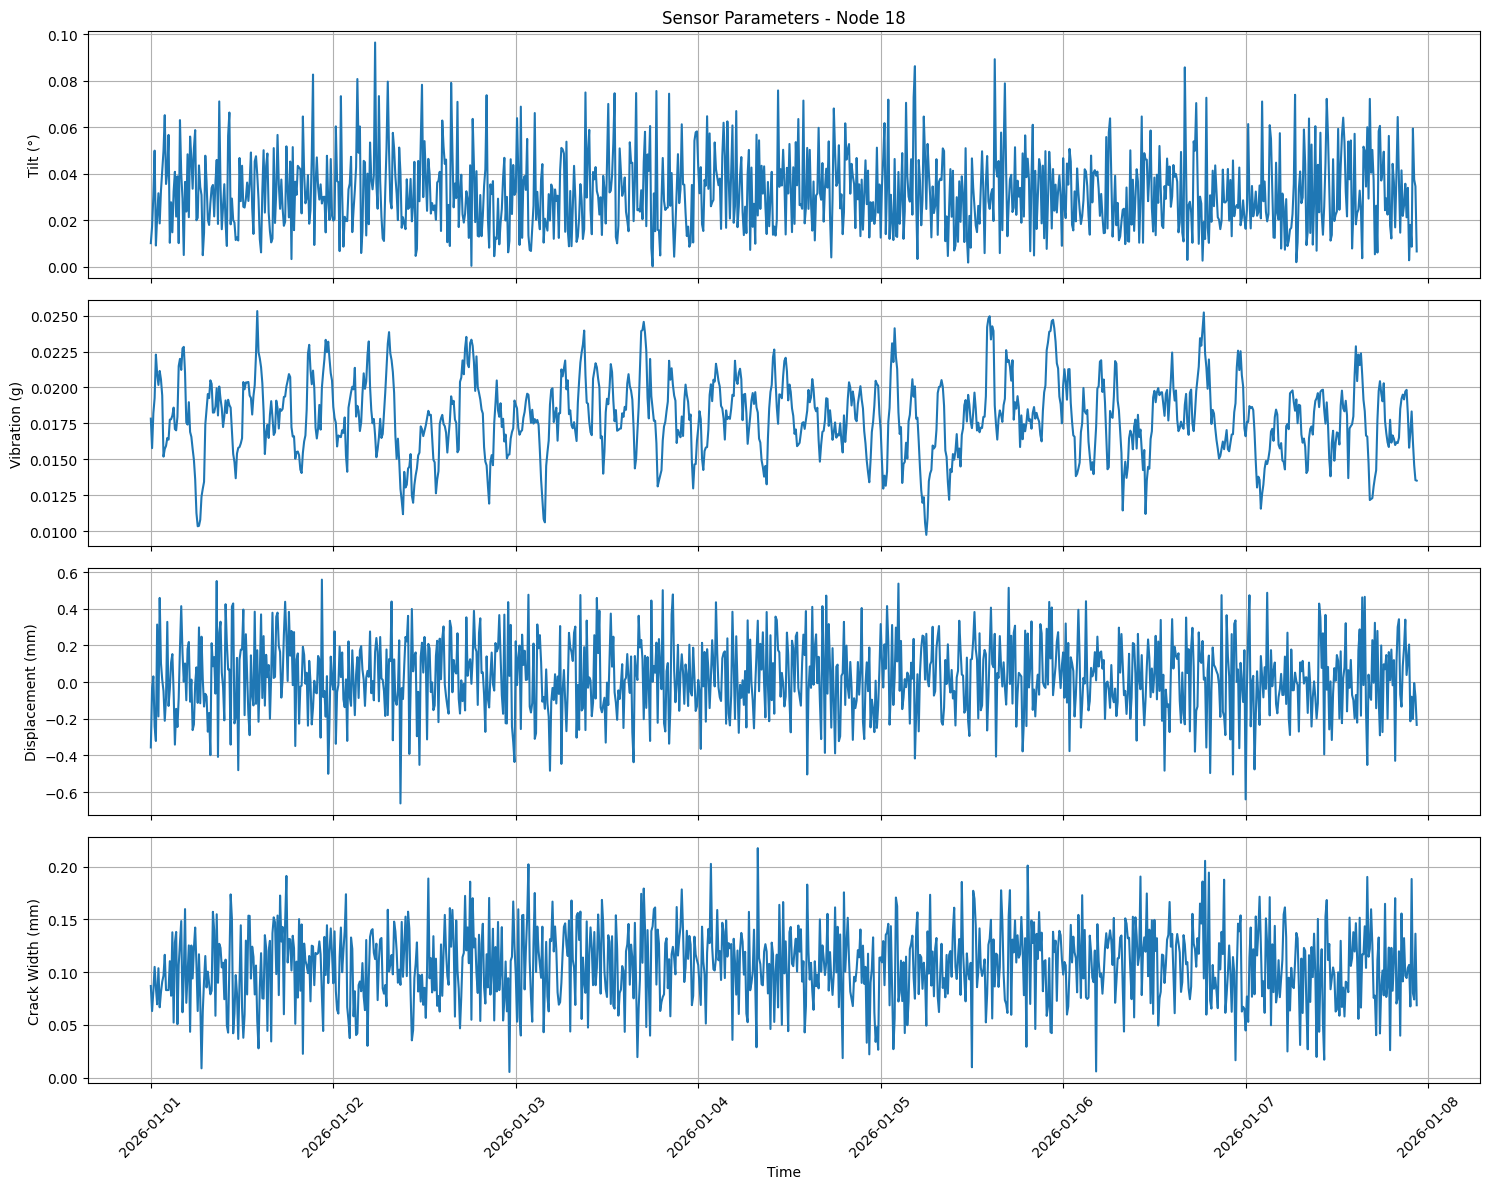

In [43]:
import matplotlib.pyplot as plt

node = test_df["node_id"].iloc[0]
node_data = test_df[test_df["node_id"] == node].sort_values("timestamp_utc").head(1000)

fig, axes = plt.subplots(4, 1, figsize=(15, 12), sharex=True)

axes[0].plot(node_data["timestamp_utc"], node_data["tilt_magnitude_deg"])
axes[0].set_ylabel("Tilt (°)")
axes[0].set_title(f"Sensor Parameters - Node {node}")
axes[0].grid()

axes[1].plot(node_data["timestamp_utc"], node_data["vibration_rms_1h_g"])
axes[1].set_ylabel("Vibration (g)")
axes[1].grid()

axes[2].plot(node_data["timestamp_utc"], node_data["relative_displacement_mm"])
axes[2].set_ylabel("Displacement (mm)")
axes[2].grid()

axes[3].plot(node_data["timestamp_utc"], node_data["crack_width_mm"])
axes[3].set_ylabel("Crack Width (mm)")
axes[3].set_xlabel("Time")
axes[3].grid()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

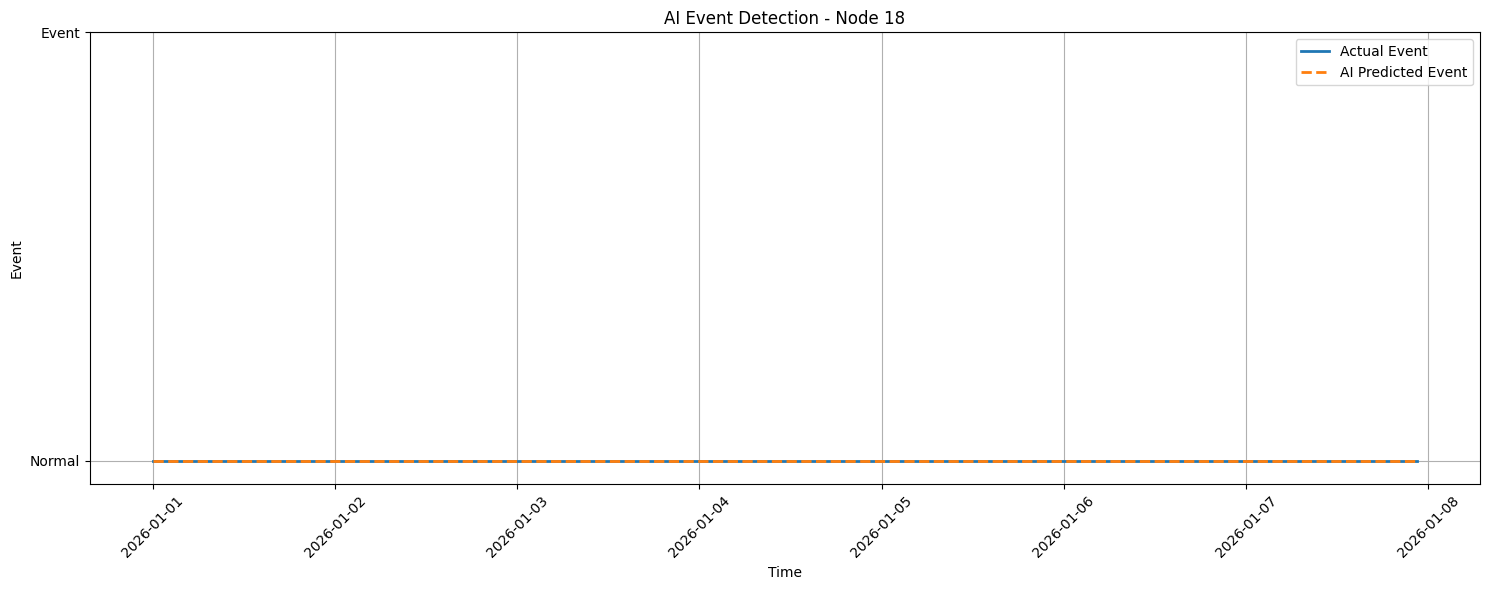

In [44]:
import matplotlib.pyplot as plt
import pandas as pd

results = test_df[[
    "timestamp_utc",
    "node_id",
    "tilt_magnitude_deg",
    "vibration_rms_1h_g",
    "relative_displacement_mm",
    "crack_width_mm"
]].copy()

results["actual_event"] = y_test.values
results["predicted_event"] = y_test_pred
results["prediction_probability"] = y_test_prob

node = results["node_id"].iloc[0]
node_results = results[results["node_id"] == node].sort_values("timestamp_utc").head(1000)

plt.figure(figsize=(15,6))

plt.plot(
    node_results["timestamp_utc"],
    node_results["actual_event"],
    label="Actual Event",
    linewidth=2
)

plt.plot(
    node_results["timestamp_utc"],
    node_results["predicted_event"],
    "--",
    label="AI Predicted Event",
    linewidth=2
)

plt.xlabel("Time")
plt.ylabel("Event")
plt.title(f"AI Event Detection - Node {node}")
plt.yticks([0, 1], ["Normal", "Event"])
plt.legend()
plt.grid()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

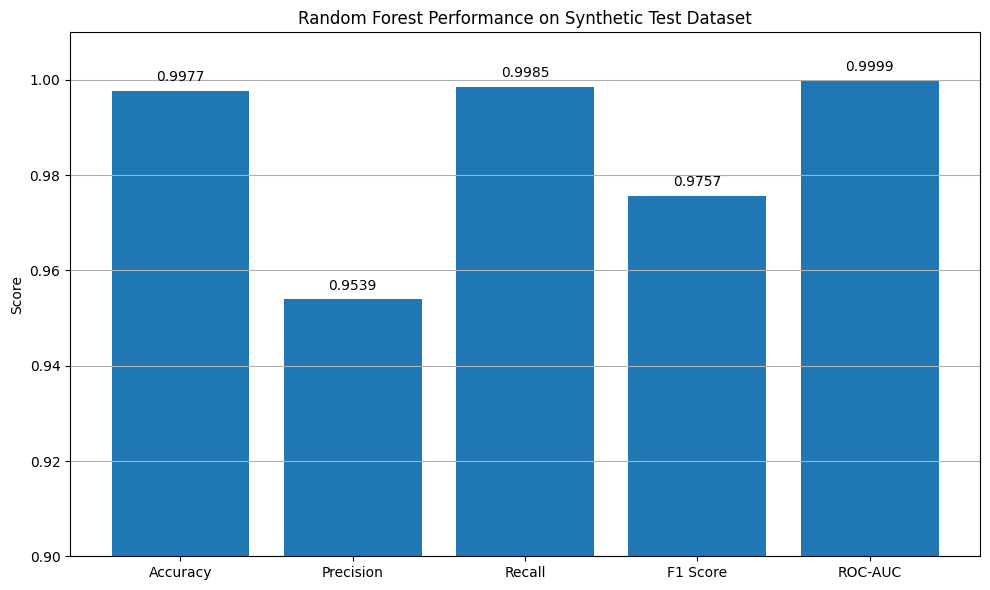

In [45]:
import matplotlib.pyplot as plt

metrics = {
    "Accuracy": accuracy_score(y_test, y_test_pred),
    "Precision": precision_score(y_test, y_test_pred),
    "Recall": recall_score(y_test, y_test_pred),
    "F1 Score": f1_score(y_test, y_test_pred),
    "ROC-AUC": roc_auc_score(y_test, y_test_prob)
}

plt.figure(figsize=(10,6))
bars = plt.bar(metrics.keys(), metrics.values())

plt.ylim(0.9, 1.01)
plt.ylabel("Score")
plt.title("Random Forest Performance on Synthetic Test Dataset")

for bar, value in zip(bars, metrics.values()):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 0.002,
        f"{value:.4f}",
        ha="center"
    )

plt.grid(axis="y")
plt.tight_layout()
plt.show()

In [46]:
import joblib
import json

joblib.dump(model, "mine_subsidence_event_model.pkl")

results = {
    "model": "Random Forest Classifier",
    "dataset": "mine_subsidence_100k_synthetic_ml_dataset",
    "test_accuracy": float(accuracy_score(y_test, y_test_pred)),
    "test_precision": float(precision_score(y_test, y_test_pred)),
    "test_recall": float(recall_score(y_test, y_test_pred)),
    "test_f1": float(f1_score(y_test, y_test_pred)),
    "test_roc_auc": float(roc_auc_score(y_test, y_test_prob)),
    "confusion_matrix": confusion_matrix(y_test, y_test_pred).tolist()
}

with open("model_results.json", "w") as f:
    json.dump(results, f, indent=4)

print("Model saved: mine_subsidence_event_model.pkl")
print("Results saved: model_results.json")

Model saved: mine_subsidence_event_model.pkl
Results saved: model_results.json


In [47]:
from google.colab import files

files.download("mine_subsidence_event_model.pkl")
files.download("model_results.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [48]:
print("=" * 50)
print("MINE SUBSIDENCE AI MODEL - FINAL RESULTS")
print("=" * 50)

print(f"Model       : Random Forest Classifier")
print(f"Test Samples: {len(y_test)}")
print(f"Accuracy    : {accuracy_score(y_test, y_test_pred)*100:.2f}%")
print(f"Precision   : {precision_score(y_test, y_test_pred)*100:.2f}%")
print(f"Recall      : {recall_score(y_test, y_test_pred)*100:.2f}%")
print(f"F1 Score    : {f1_score(y_test, y_test_pred)*100:.2f}%")
print(f"ROC-AUC     : {roc_auc_score(y_test, y_test_prob):.4f}")

cm = confusion_matrix(y_test, y_test_pred)

print("\nCONFUSION MATRIX")
print(f"True Negatives : {cm[0,0]}")
print(f"False Positives: {cm[0,1]}")
print(f"False Negatives: {cm[1,0]}")
print(f"True Positives : {cm[1,1]}")

print("\nModel and results successfully saved.")

MINE SUBSIDENCE AI MODEL - FINAL RESULTS
Model       : Random Forest Classifier
Test Samples: 15000
Accuracy    : 99.77%
Precision   : 95.39%
Recall      : 99.85%
F1 Score    : 97.57%
ROC-AUC     : 0.9999

CONFUSION MATRIX
True Negatives : 14283
False Positives: 33
False Negatives: 1
True Positives : 683

Model and results successfully saved.


In [49]:
import joblib
import pandas as pd
import numpy as np

model = joblib.load("mine_subsidence_event_model.pkl")

print("Model loaded successfully.")

Model loaded successfully.


In [50]:
def predict_subsidence_risk(sensor_data):

    input_data = pd.DataFrame([sensor_data])

    probability = model.predict_proba(input_data)[0][1]
    prediction = model.predict(input_data)[0]

    if probability >= 0.80:
        risk = "CRITICAL"
        action = "ACTIVATE SIREN + SEND ALERT"
    elif probability >= 0.50:
        risk = "WARNING"
        action = "SEND WARNING"
    else:
        risk = "NORMAL"
        action = "CONTINUE MONITORING"

    return {
        "prediction": int(prediction),
        "probability": round(float(probability), 4),
        "risk_level": risk,
        "action": action
    }

In [51]:
sample = X_test.iloc[0].to_dict()

result = predict_subsidence_risk(sample)

print("AI REAL-TIME PREDICTION")
print("-----------------------")
print("Prediction :", result["prediction"])
print("Probability:", result["probability"])
print("Risk Level :", result["risk_level"])
print("Action     :", result["action"])

AI REAL-TIME PREDICTION
-----------------------
Prediction : 0
Probability: 0.0
Risk Level : NORMAL
Action     : CONTINUE MONITORING


In [52]:
normal_row = X_test[y_test.values == 0].iloc[0].to_dict()
event_row = X_test[y_test.values == 1].iloc[0].to_dict()

normal_result = predict_subsidence_risk(normal_row)
event_result = predict_subsidence_risk(event_row)

print("NORMAL CASE")
print("Prediction :", normal_result["prediction"])
print("Probability:", normal_result["probability"])
print("Risk Level :", normal_result["risk_level"])
print("Action     :", normal_result["action"])

print("\nEVENT CASE")
print("Prediction :", event_result["prediction"])
print("Probability:", event_result["probability"])
print("Risk Level :", event_result["risk_level"])
print("Action     :", event_result["action"])

NORMAL CASE
Prediction : 0
Probability: 0.0
Risk Level : NORMAL
Action     : CONTINUE MONITORING

EVENT CASE
Prediction : 1
Probability: 0.5738
Risk Level : WARNING
Action     : SEND WARNING


In [53]:
print("=" * 60)
print("AI-ENABLED MINE SUBSIDENCE MONITORING SYSTEM")
print("=" * 60)

print("\nMODEL")
print("Random Forest Classifier")

print("\nDATASET")
print("100,000 synthetic sensor records")
print("18 sensor/environment features")
print("Target: synthetic_event")

print("\nTEST PERFORMANCE")
print(f"Accuracy : {accuracy_score(y_test, y_test_pred)*100:.2f}%")
print(f"Precision: {precision_score(y_test, y_test_pred)*100:.2f}%")
print(f"Recall   : {recall_score(y_test, y_test_pred)*100:.2f}%")
print(f"F1 Score : {f1_score(y_test, y_test_pred)*100:.2f}%")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_test_prob):.4f}")

print("\nEARLY-WARNING RELEVANCE")
print("False Negatives:", confusion_matrix(y_test, y_test_pred)[1,0])
print("False Positives:", confusion_matrix(y_test, y_test_pred)[0,1])

print("\nSYSTEM FLOW")
print("Sensors -> ESP32 -> LoRa -> Gateway -> AI -> Risk -> Alert")

print("\nSTATUS")
print("AI prototype validated on synthetic test data")
print("Real-mine field validation required before deployment")

AI-ENABLED MINE SUBSIDENCE MONITORING SYSTEM

MODEL
Random Forest Classifier

DATASET
100,000 synthetic sensor records
18 sensor/environment features
Target: synthetic_event

TEST PERFORMANCE
Accuracy : 99.77%
Precision: 95.39%
Recall   : 99.85%
F1 Score : 97.57%
ROC-AUC  : 0.9999

EARLY-WARNING RELEVANCE
False Negatives: 1
False Positives: 33

SYSTEM FLOW
Sensors -> ESP32 -> LoRa -> Gateway -> AI -> Risk -> Alert

STATUS
AI prototype validated on synthetic test data
Real-mine field validation required before deployment
